In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2 as cv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
import os

In [ ]:

# ! only for colab run
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

# ! only for colab run
# !unzip drive/MyDrive/multilabel_modified.zip

## data loading

In [ ]:
# df = pd.read_csv("multilabel_modified/multilabel_classification(7).csv") # ? colab run
df = pd.read_csv("data/multilabel_modified/multilabel_classification(7).csv") # ? local run

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7943 entries, 0 to 7942
Data columns (total 2 columns):
 #   Column                                                                                              Non-Null Count  Dtype
---  ------                                                                                              --------------  -----
 0   Image_Name                                                                                          7943 non-null   str  
 1    Classes(motorcycle, truck, boat, bus, cycle, , , , , , , sitar, ektara, flutes, tabla, harmonium)  7943 non-null   str  
dtypes: str(2)
memory usage: 299.0 KB


In [4]:
df.columns

Index(['Image_Name', ' Classes(motorcycle, truck, boat, bus, cycle, , , , , , , sitar, ektara, flutes, tabla, harmonium)'], dtype='str')

In [5]:
df.rename(columns= {' Classes(motorcycle, truck, boat, bus, cycle, , , , , , , sitar, ektara, flutes, tabla, harmonium)' : "labels"}, inplace= True)

In [6]:
df.columns

Index(['Image_Name', 'labels'], dtype='str')

In [ ]:
# dir_ = "multilabel_modified/images/" # ? colab run
dir_ = "data/multilabel_modified/images/" # ? local run

In [8]:
imgs = set(os.listdir(dir_))

In [9]:
imgs

{'image2787.jpg',
 'image7.jpg',
 'image822.jpg',
 'image4594.jpg',
 'image5035.jpg',
 'image3668.jpg',
 'image1324.jpg',
 'image4135.jpg',
 'image5946.jpg',
 'image1522.jpg',
 'image3111.jpg',
 'image2168.jpg',
 'image4713.jpg',
 'image5070.jpg',
 'image6275.jpg',
 'image4935.jpg',
 'image6743.jpg',
 'image6093.jpg',
 'image3399.jpg',
 'image935.jpg',
 'image2859.jpg',
 'image1939.jpg',
 'image2840.jpg',
 'image5815.jpg',
 'image553.jpg',
 'image909.jpg',
 'image2202.jpg',
 'image5497.jpg',
 'image2085.jpg',
 'image648.jpg',
 'image1250.jpg',
 'image2471.jpg',
 'image4813.jpg',
 'image602.jpg',
 'image1675.jpg',
 'image2298.jpg',
 'image3535.jpg',
 'image3377.jpg',
 'image3811.jpg',
 'image6637.jpg',
 'image1942.jpg',
 'image1891.jpg',
 'image6478.jpg',
 'image3382.jpg',
 'image7568.jpg',
 'image1807.jpg',
 'image7704.jpg',
 'image2860.jpg',
 'image4819.jpg',
 'image2162.jpg',
 'image7514.jpg',
 'image6745.jpg',
 'image3539.jpg',
 'image3184.jpg',
 'image1641.jpg',
 'image7430.jpg',
 

In [10]:
df = df[df["Image_Name"].apply(lambda x: x in imgs)]

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7943 entries, 0 to 7942
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Image_Name  7943 non-null   str  
 1   labels      7943 non-null   str  
dtypes: str(2)
memory usage: 299.0 KB


## pre process

In [12]:
def img_preprocess(dirname):
    img = cv.imread(dirname)
    img = cv.resize(img, (150, 150))
    return img / 255.0

In [13]:
images = []
labels = []

for i, row in df.iterrows():
    img_name = row["Image_Name"]
    img_path = os.path.join(dir_, img_name)

    if os.path.exists(img_path):
        images.append(img_preprocess(img_path))
        labels.append(row["labels"].split())

In [16]:
mlb = MultiLabelBinarizer()
labels = mlb.fit_transform(labels)

In [17]:
mlb.classes_

array(['boat', 'bus', 'cycle', 'ektara', 'flutes', 'harmonium',
       'motorcycle', 'sitar', 'tabla', 'truck'], dtype=object)

In [18]:
labels

array([[0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 1, 0],
       [0, 0, 0, ..., 0, 1, 0],
       [0, 0, 0, ..., 0, 1, 0]])

In [19]:
labels_df = pd.DataFrame(data= labels, columns= mlb.classes_)

In [20]:
labels_df.head()

,boat,bus,cycle,ektara,flutes,harmonium,motorcycle,sitar,tabla,truck
0,0,1,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,1,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0


/tmp/ipykernel_1613/4083798618.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x= labels_df.iloc[:, 0], ax= axs.flatten()[0], palette= "Set1")
/tmp/ipykernel_1613/4083798618.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x= labels_df.iloc[:, 1], ax= axs.flatten()[1], palette= "Set1")
/tmp/ipykernel_1613/4083798618.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x= labels_df.iloc[:, 2], ax= axs.flatten()[2], palette= "Set1")
/tmp/ipykernel_1613/4083798618.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is d

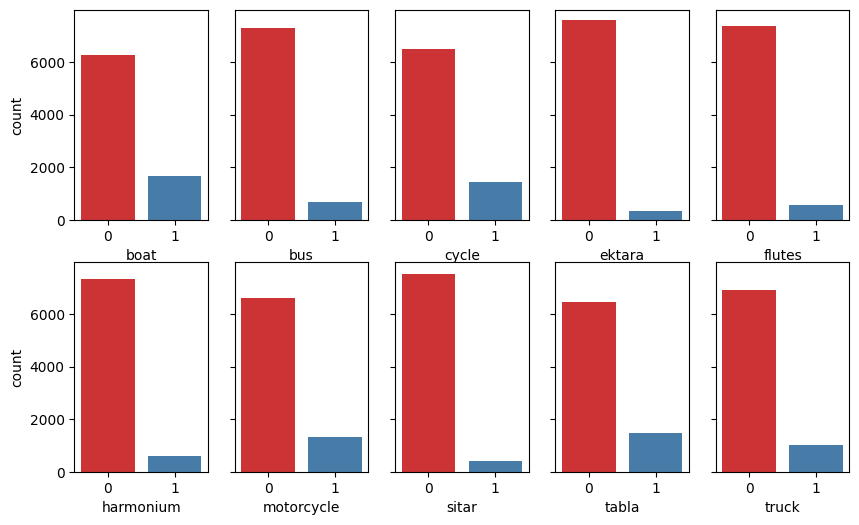

In [21]:
fig, axs = plt.subplots(nrows=2, ncols= 5, sharey= True)
fig.set_figwidth(10)
fig.set_figheight(6)
sns.countplot(x= labels_df.iloc[:, 0], ax= axs.flatten()[0], palette= "Set1")
sns.countplot(x= labels_df.iloc[:, 1], ax= axs.flatten()[1], palette= "Set1")
sns.countplot(x= labels_df.iloc[:, 2], ax= axs.flatten()[2], palette= "Set1")
sns.countplot(x= labels_df.iloc[:, 3], ax= axs.flatten()[3], palette= "Set1")
sns.countplot(x= labels_df.iloc[:, 4], ax= axs.flatten()[4], palette= "Set1")
sns.countplot(x= labels_df.iloc[:, 5], ax= axs.flatten()[5], palette= "Set1")
sns.countplot(x= labels_df.iloc[:, 6], ax= axs.flatten()[6], palette= "Set1")
sns.countplot(x= labels_df.iloc[:, 7], ax= axs.flatten()[7], palette= "Set1")
sns.countplot(x= labels_df.iloc[:, 8], ax= axs.flatten()[8], palette= "Set1")
sns.countplot(x= labels_df.iloc[:, 9], ax= axs.flatten()[9], palette= "Set1")
plt.show()

In [22]:
labels_df.sum(axis= 1).max()
# this means there are images whith at most 4 possible target

4

In [23]:
labels_df.sum(axis= 1).value_counts().index

Index([1, 2, 3, 4], dtype='int64')

/tmp/ipykernel_1613/3121619491.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x= labels_df.sum(axis= 1).value_counts().index, y= labels_df.sum(axis= 1).value_counts().values, palette= "Set1")


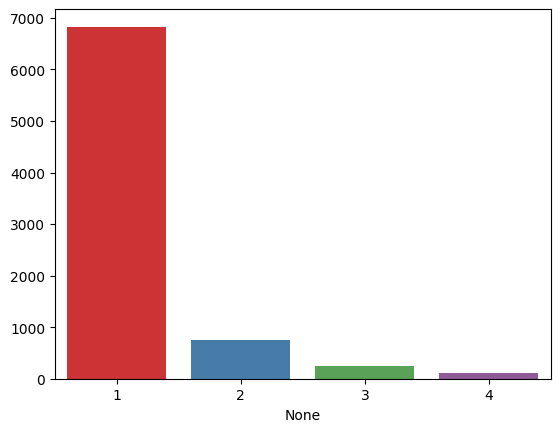

In [24]:
sns.barplot(x= labels_df.sum(axis= 1).value_counts().index, y= labels_df.sum(axis= 1).value_counts().values, palette= "Set1")
plt.show()

In [25]:
images = np.array(images)

In [26]:
type(images)

numpy.ndarray

In [27]:
images.dtype

dtype('float64')

In [28]:
type(labels)

numpy.ndarray

In [29]:
labels.dtype

dtype('int64')

In [30]:
del df, imgs, dir_, mlb, labels_df, fig, axs, pd, plt, sns, cv, MultiLabelBinarizer, os, i, img_name, img_path, row

In [31]:
X_train, X_val_test, y_train, y_val_test = train_test_split(images, labels, test_size= .3, shuffle= True, random_state= 12)

In [32]:
del images, labels

In [33]:
X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, test_size= .5, shuffle= True, random_state= 12)

In [34]:
del X_val_test, y_val_test

## model making

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), padding= "same", activation= "relu", input_shape= (150, 150, 3)),
    tf.keras.layers.MaxPool2D(2, 2, padding= "same"),
    tf.keras.layers.Conv2D(64, (3, 3), padding= "valid", activation= "relu"),
    tf.keras.layers.MaxPool2D(2, 2, padding= "valid"),
    tf.keras.layers.Conv2D(128, (3, 3), padding= "valid", activation= "relu"),
    tf.keras.layers.MaxPool2D(2, 2, padding= "valid"),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation= "relu"),
    tf.keras.layers.Dropout(.3),
    tf.keras.layers.Dense(64, activation= "relu"),
    tf.keras.layers.Dropout(.3),
    tf.keras.layers.Dense(10, activation= "sigmoid")
])

In [ ]:
model.summary()

In [ ]:
tf.keras.utils.plot_model(model, show_shapes= True)

In [ ]:
model.compile(
    optimizer= tf.keras.optimizers.Adam(learning_rate= .001),
    loss= tf.keras.losses.BinaryCrossentropy(),
    metrics= [
    "accuracy"
    ]
    )

In [ ]:
early_stop = EarlyStopping(monitor= "val_loss", patience= 10, restore_best_weights= True, verbose= 1, start_from_epoch= 2)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    batch_size= 2,
    epochs= 20,
    callbacks= [early_stop],
    validation_data= (X_val, y_val)
)

In [ ]:
model.save("/models/uni_project_first_model_3_epochs_early_stopped.keras")

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
history.history.keys()

In [ ]:
history.params

In [45]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

In [46]:
print(f"validation accuracy at epoch 3: {val_accuracy[2]}")
print(f"validation loss at epoch 3: {val_loss[2]}")

In [47]:
plt.figure(figsize= (10, 6))

plt.plot(accuracy, label= "train accuracy")
plt.plot(val_accuracy, label= "validation accuracy")
plt.title("model accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend(loc= "upper left")
plt.show()

In [48]:
plt.figure(figsize= (10, 6))

plt.plot(loss, label= "train loss")
plt.plot(val_loss, label= "validation loss")
plt.title("model loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend(loc= "upper left")
plt.show()

In [49]:
plt.figure(figsize= (10, 6))

plt.plot(accuracy, label= "train accuracy")
plt.plot(loss, label= "train loss")
plt.title("training accuracy - loss")
plt.xlabel("epoch")
plt.ylabel("accuracy - loss")
plt.legend(loc= "upper left")
plt.show()

In [50]:
plt.figure(figsize= (10, 6))

plt.plot(val_accuracy, label= "validation accuracy")
plt.plot(val_loss, label= "validation loss")
plt.title("validation accuracy - loss")
plt.xlabel("epoch")
plt.ylabel("accuracy - loss")
plt.legend(loc= "upper left")
plt.show()

In [56]:
model = tf.keras.models.load_model("/models/uni_project_first_model_3_epochs_early_stopped.keras")

In [57]:
model.evaluate(X_val, y_val, batch_size= 2)

596/596 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7078 - loss: 0.1323


[0.13225157558918, 0.7078085541725159]

In [58]:
model.evaluate(X_test, y_test, batch_size= 2)

596/596 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6737 - loss: 0.1422


[0.14222046732902527, 0.6736577153205872]

In [59]:
y_pred = model.predict(X_test, batch_size= 2)

596/596 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [60]:
y_pred = (y_pred >= .5).astype(np.int_)

In [62]:
from sklearn.metrics import accuracy_score, classification_report

In [63]:
accuracy_score(y_test, y_pred)

0.6401006711409396

In [65]:
del X_train, y_train, X_val, y_val

In [ ]:
# import pandas as pd
# import os
# from sklearn.preprocessing import MultiLabelBinarizer

In [ ]:
# df = pd.read_csv("multilabel_modified/multilabel_classification(7).csv") # ! colab run
# df = pd.read_csv("data/multilabel_modified/multilabel_classification(7).csv") # ! local run

In [ ]:
# df.rename(columns= {' Classes(motorcycle, truck, boat, bus, cycle, , , , , , , sitar, ektara, flutes, tabla, harmonium)' : "labels"}, inplace= True)

In [ ]:
# dir_ = "multilabel_modified/images" # ! colab run
# dir_ = "data/multilabel_modified/images" # ! local run

In [ ]:
# imgs = set(os.listdir(dir_))

In [ ]:
# df = df[df["Image_Name"].apply(lambda x: x in imgs)]

In [ ]:
# labels = []

# for i, row in df.iterrows():
#     img_name = row["Image_Name"]
#     img_path = os.path.join(dir_, img_name)

#     if os.path.exists(img_path):
#         labels.append(row["labels"].split())

In [ ]:
# mlb = MultiLabelBinarizer()
# labels = mlb.fit_transform(labels)

In [ ]:
# print(classification_report(y_test, y_pred, target_names= mlb.classes_))
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        boat       0.74      0.77      0.76       251
         bus       0.95      0.18      0.31       109
       cycle       0.85      0.79      0.82       224
      ektara       1.00      0.63      0.77        54
      flutes       0.93      0.88      0.90        85
   harmonium       1.00      0.79      0.88       103
  motorcycle       0.75      0.68      0.71       208
       sitar       1.00      0.73      0.84        59
       tabla       0.96      0.84      0.90       226
       truck       0.67      0.45      0.54       130

   micro avg       0.84      0.70      0.76      1449
   macro avg       0.89      0.67      0.74      1449
weighted avg       0.85      0.70      0.75      1449
 samples avg       0.67      0.66      0.66      1449



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
